# Phase 3 filter diagnostics

Histograms for the quality filters and deduplication metrics applied to the dataset produced by `curate_phase3_p3m_keep70_dataset`.

In [7]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

import src.TemporaryClean as TemporaryClean
from src.phase3.config import (
    PHASE3_BLUR_THRESHOLD,
    PHASE3_DARKNESS_THRESHOLD,
    PHASE3_IMAGES_DIR,
    PHASE3_MODEL_GUIDED_CSV,
    PHASE3_PHASH_THRESHOLD,
    PHASE3_SSIM_THRESHOLD,
    PHASE3_UNIFORMITY_THRESHOLD,
)
from utils.common import read_csv, resolve_data_path, write_csv
from utils.phase3.deduplication import calculate_phase3_metrics


PHASE3_CSV = PHASE3_MODEL_GUIDED_CSV
PHASE3_IMAGES = PHASE3_IMAGES_DIR
METRICS_CACHE_CSV = Path(PHASE3_CSV).with_name(f"{Path(PHASE3_CSV).stem}_metrics.csv")
SIMILARITY_PAIRS_CACHE_CSV = Path(PHASE3_CSV).with_name(
    f"{Path(PHASE3_CSV).stem}_similarity_pairs.csv"
)


def build_cutoff_summary(
    values: pd.Series,
    threshold: float,
    percentiles: tuple[int, ...],
    keep_rule: str,
    count_label: str,
) -> pd.DataFrame:
    values = pd.to_numeric(values, errors="coerce").dropna()

    rows = [
        {
            "cutoff": "threshold",
            "percentile": pd.NA,
            "value": float(threshold),
        }
    ]
    rows.extend(
        {
            "cutoff": f"p{percentile}",
            "percentile": percentile,
            "value": float(values.quantile(percentile / 100)),
        }
        for percentile in percentiles
    )

    summary_df = pd.DataFrame(rows)
    if keep_rule == "ge":
        summary_df[count_label] = summary_df["value"].map(lambda cutoff: int((values >= cutoff).sum()))
    elif keep_rule == "le":
        summary_df[count_label] = summary_df["value"].map(lambda cutoff: int((values <= cutoff).sum()))
    else:
        raise ValueError("keep_rule must be 'ge' or 'le'.")

    summary_df["total"] = len(values)
    summary_df["percentage"] = (summary_df[count_label] / len(values) * 100).round(2)
    return summary_df


def print_cutoff_summary(title: str, summary_df: pd.DataFrame, count_label: str) -> None:
    print(title)
    for _, row in summary_df.iterrows():
        print(
            f"- {row['cutoff']}: value={row['value']:.4f}, "
            f"{count_label}={int(row[count_label])}/{int(row['total'])} "
            f"({row['percentage']:.2f}%)"
        )


def plot_threshold_histogram(
    dataframe: pd.DataFrame,
    column: str,
    threshold: float,
    title: str,
    xlabel: str,
    percentiles: tuple[int, ...] = (10, 25),
    keep_rule: str = "ge",
    count_label: str = "n_keep",
    bins: int = 60,
) -> pd.DataFrame:
    values = pd.to_numeric(dataframe[column], errors="coerce").dropna()
    summary_df = build_cutoff_summary(
        values=values,
        threshold=threshold,
        percentiles=percentiles,
        keep_rule=keep_rule,
        count_label=count_label,
    )

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(values, bins=bins, color="#4C78A8", alpha=0.85, edgecolor="white")

    for _, row in summary_df.iterrows():
        is_threshold = row["cutoff"] == "threshold"
        ax.axvline(
            row["value"],
            color="#D62728" if is_threshold else "#F28E2B",
            linestyle="--" if is_threshold else ":",
            linewidth=2 if is_threshold else 1.8,
            label=f"{row['cutoff']} = {row['value']:.2f} | {count_label} = {int(row[count_label])}",
        )

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Images")
    ax.legend()
    ax.grid(axis="y", alpha=0.25)
    plt.show()

    print_cutoff_summary(title, summary_df, count_label)
    return summary_df


In [8]:
phase3_csv_path = resolve_data_path(PHASE3_CSV)
phase3_images_path = resolve_data_path(PHASE3_IMAGES)
metrics_cache_path = resolve_data_path(METRICS_CACHE_CSV)

if metrics_cache_path.exists():
    metrics_df = read_csv(metrics_cache_path)
else:
    metrics_df = calculate_phase3_metrics(
        dataframe_or_csv=phase3_csv_path,
        images_dir=phase3_images_path,
    )
    write_csv(metrics_df, metrics_cache_path)

summary_df = metrics_df[
    ["brightness_v_mean", "uniformity_entropy", "laplacian_variance"]
].describe().T


In [9]:
filter_columns = {
    "darkness": "brightness_v_mean",
    "uniformity": "uniformity_entropy",
    "blur": "laplacian_variance",
}

combined_rows = [
    {
        "setting": "no_filter",
        "darkness_cutoff": pd.NA,
        "uniformity_cutoff": pd.NA,
        "blur_cutoff": pd.NA,
        "n_keep": len(metrics_df),
        "total": len(metrics_df),
        "percentage": 100.0,
    }
]

for percentile in (10, 25):
    cutoffs = {
        name: pd.to_numeric(metrics_df[column], errors="coerce").quantile(percentile / 100)
        for name, column in filter_columns.items()
    }
    keep_mask = pd.Series(True, index=metrics_df.index)
    for name, column in filter_columns.items():
        keep_mask &= pd.to_numeric(metrics_df[column], errors="coerce") >= cutoffs[name]

    n_keep = int(keep_mask.sum())
    combined_rows.append(
        {
            "setting": f"all_p{percentile}",
            "darkness_cutoff": cutoffs["darkness"],
            "uniformity_cutoff": cutoffs["uniformity"],
            "blur_cutoff": cutoffs["blur"],
            "n_keep": n_keep,
            "total": len(metrics_df),
            "percentage": round(n_keep / len(metrics_df) * 100, 2),
        }
    )

combined_filter_counts_df = pd.DataFrame(combined_rows)

print("Combined quality-filter counts")
for _, row in combined_filter_counts_df.iterrows():
    print(
        f"- {row['setting']}: n_keep={int(row['n_keep'])}/{int(row['total'])} "
        f"({row['percentage']:.2f}%)"
    )

display(combined_filter_counts_df)


Combined quality-filter counts
- no_filter: n_keep=10128/10128 (100.00%)
- all_p10: n_keep=7621/10128 (75.25%)
- all_p25: n_keep=4577/10128 (45.19%)


,setting,darkness_cutoff,uniformity_cutoff,blur_cutoff,n_keep,total,percentage
0,no_filter,<NA>,<NA>,<NA>,10128,10128,100.00
1,all_p10,87.752572,6.648149,92.480609,7621,10128,75.25
2,all_p25,110.354445,6.900802,138.780256,4577,10128,45.19


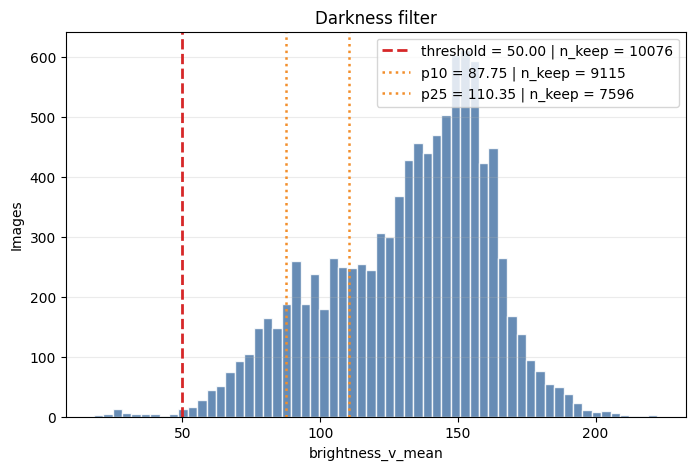

Darkness filter
- threshold: value=50.0000, n_keep=10076/10128 (99.49%)
- p10: value=87.7526, n_keep=9115/10128 (90.00%)
- p25: value=110.3544, n_keep=7596/10128 (75.00%)


,cutoff,percentile,value,n_keep,total,percentage
0,threshold,<NA>,50.000000,10076,10128,99.49
1,p10,10,87.752572,9115,10128,90.00
2,p25,25,110.354445,7596,10128,75.00


In [10]:
plot_threshold_histogram(
    dataframe=metrics_df,
    column="brightness_v_mean",
    threshold=PHASE3_DARKNESS_THRESHOLD,
    title="Darkness filter",
    xlabel="brightness_v_mean",
)


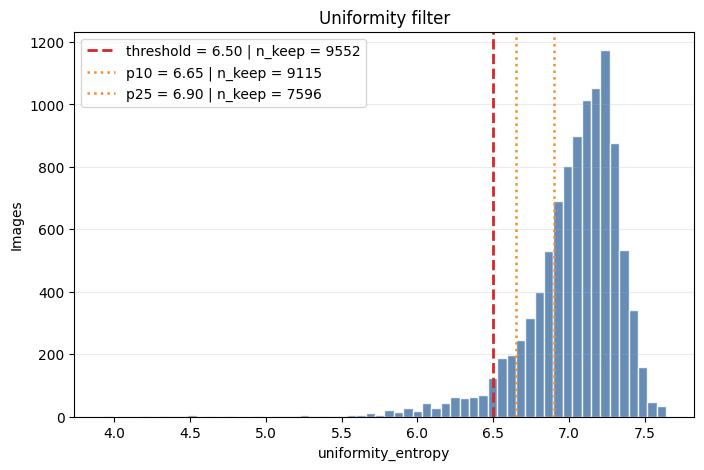

Uniformity filter
- threshold: value=6.5000, n_keep=9552/10128 (94.31%)
- p10: value=6.6481, n_keep=9115/10128 (90.00%)
- p25: value=6.9008, n_keep=7596/10128 (75.00%)


,cutoff,percentile,value,n_keep,total,percentage
0,threshold,<NA>,6.500000,9552,10128,94.31
1,p10,10,6.648149,9115,10128,90.00
2,p25,25,6.900802,7596,10128,75.00


In [11]:
plot_threshold_histogram(
    dataframe=metrics_df,
    column="uniformity_entropy",
    threshold=PHASE3_UNIFORMITY_THRESHOLD,
    title="Uniformity filter",
    xlabel="uniformity_entropy",
)


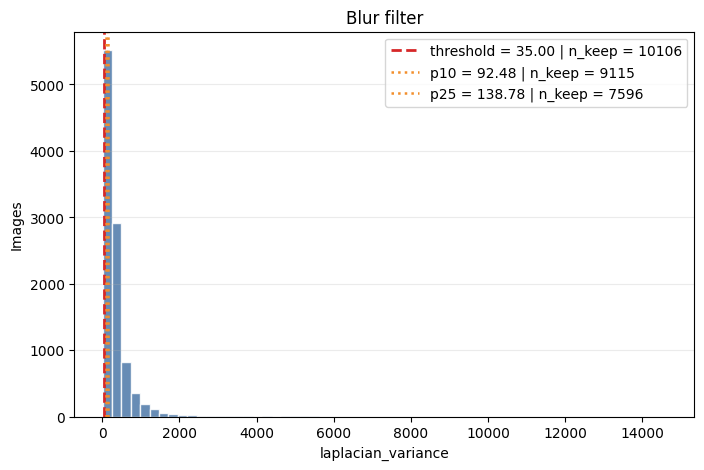

Blur filter
- threshold: value=35.0000, n_keep=10106/10128 (99.78%)
- p10: value=92.4806, n_keep=9115/10128 (90.00%)
- p25: value=138.7803, n_keep=7596/10128 (75.00%)


,cutoff,percentile,value,n_keep,total,percentage
0,threshold,<NA>,35.000000,10106,10128,99.78
1,p10,10,92.480609,9115,10128,90.00
2,p25,25,138.780256,7596,10128,75.00


In [12]:
plot_threshold_histogram(
    dataframe=metrics_df,
    column="laplacian_variance",
    threshold=PHASE3_BLUR_THRESHOLD,
    title="Blur filter",
    xlabel="laplacian_variance",
)


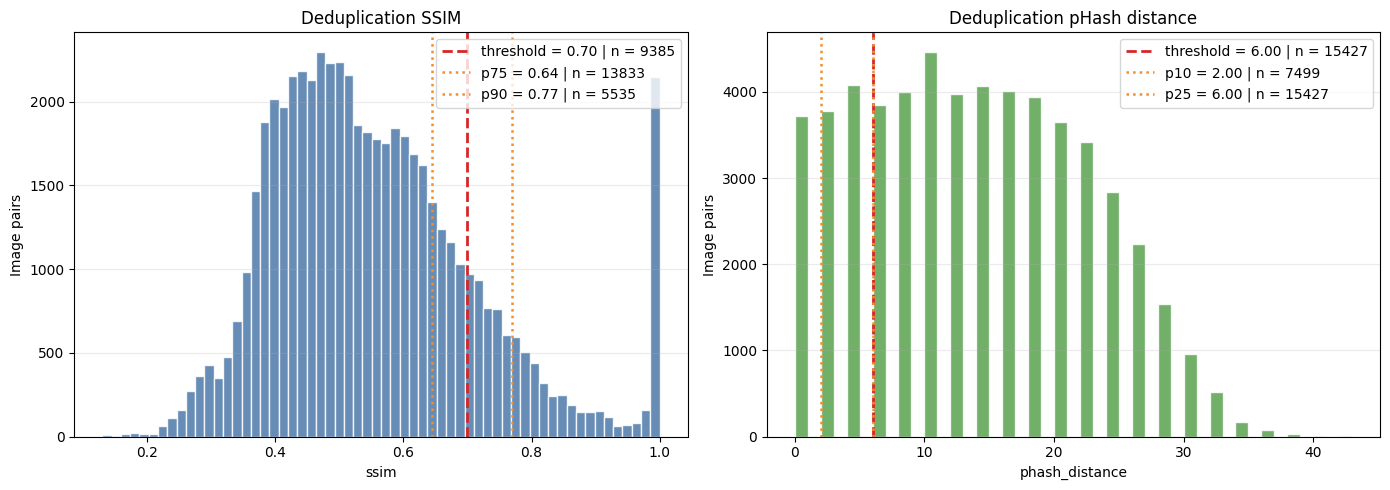

Deduplication SSIM
- threshold: value=0.7000, n_pairs_condition=9385/55326 (16.96%)
- p75: value=0.6441, n_pairs_condition=13833/55326 (25.00%)
- p90: value=0.7702, n_pairs_condition=5535/55326 (10.00%)
Deduplication pHash distance
- threshold: value=6.0000, n_pairs_condition=15427/55326 (27.88%)
- p10: value=2.0000, n_pairs_condition=7499/55326 (13.55%)
- p25: value=6.0000, n_pairs_condition=15427/55326 (27.88%)


,metric,value
0,comparable_pairs,55326
1,redundant_by_ssim,9385
2,redundant_by_phash,15427
3,redundant_by_both,6076
4,ssim_threshold,0.7
5,phash_distance_threshold,6
6,similarity_pairs_cache,C:\Users\luis\Documents\TFG - Data-Centric AI\...


,cutoff,percentile,value,n_pairs_condition,total,percentage,metric
0,threshold,<NA>,0.700000,9385,55326,16.96,ssim
1,p75,75,0.644093,13833,55326,25.00,ssim
2,p90,90,0.770217,5535,55326,10.00,ssim
3,threshold,<NA>,6.000000,15427,55326,27.88,phash_distance
4,p10,10,2.000000,7499,55326,13.55,phash_distance
5,p25,25,6.000000,15427,55326,27.88,phash_distance


In [13]:
similarity_pairs_cache_path = resolve_data_path(SIMILARITY_PAIRS_CACHE_CSV)

if similarity_pairs_cache_path.exists():
    similarity_pairs_df = read_csv(similarity_pairs_cache_path)
else:
    grouped_metrics_df = TemporaryClean.add_temporal_groups(metrics_df)
    similarity_pairs_df = TemporaryClean.calculate_similarity(
        dataframe=grouped_metrics_df,
        images_dir=phase3_images_path,
        ssim_threshold=PHASE3_SSIM_THRESHOLD,
        phash_distance_threshold=PHASE3_PHASH_THRESHOLD,
    )
    write_csv(similarity_pairs_df, similarity_pairs_cache_path)

if similarity_pairs_df.empty:
    display(pd.DataFrame({"message": ["No comparable image pairs were found."]}))
else:
    ssim_values = pd.to_numeric(similarity_pairs_df["ssim"], errors="coerce").dropna()
    phash_values = pd.to_numeric(
        similarity_pairs_df["phash_distance"], errors="coerce"
    ).dropna()

    ssim_summary_df = build_cutoff_summary(
        values=ssim_values,
        threshold=PHASE3_SSIM_THRESHOLD,
        percentiles=(75, 90),
        keep_rule="ge",
        count_label="n_pairs_condition",
    )
    phash_summary_df = build_cutoff_summary(
        values=phash_values,
        threshold=PHASE3_PHASH_THRESHOLD,
        percentiles=(10, 25),
        keep_rule="le",
        count_label="n_pairs_condition",
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(ssim_values, bins=60, color="#4C78A8", alpha=0.85, edgecolor="white")
    for _, row in ssim_summary_df.iterrows():
        is_threshold = row["cutoff"] == "threshold"
        axes[0].axvline(
            row["value"],
            color="#D62728" if is_threshold else "#F28E2B",
            linestyle="--" if is_threshold else ":",
            linewidth=2 if is_threshold else 1.8,
            label=f"{row['cutoff']} = {row['value']:.2f} | n = {int(row['n_pairs_condition'])}",
        )
    axes[0].set_title("Deduplication SSIM")
    axes[0].set_xlabel("ssim")
    axes[0].set_ylabel("Image pairs")
    axes[0].legend()
    axes[0].grid(axis="y", alpha=0.25)

    phash_max = int(phash_values.max()) if not phash_values.empty else PHASE3_PHASH_THRESHOLD
    phash_bins = range(0, max(phash_max, PHASE3_PHASH_THRESHOLD) + 2)
    axes[1].hist(phash_values, bins=phash_bins, color="#59A14F", alpha=0.85, edgecolor="white")
    for _, row in phash_summary_df.iterrows():
        is_threshold = row["cutoff"] == "threshold"
        axes[1].axvline(
            row["value"],
            color="#D62728" if is_threshold else "#F28E2B",
            linestyle="--" if is_threshold else ":",
            linewidth=2 if is_threshold else 1.8,
            label=f"{row['cutoff']} = {row['value']:.2f} | n = {int(row['n_pairs_condition'])}",
        )
    axes[1].set_title("Deduplication pHash distance")
    axes[1].set_xlabel("phash_distance")
    axes[1].set_ylabel("Image pairs")
    axes[1].legend()
    axes[1].grid(axis="y", alpha=0.25)

    plt.tight_layout()
    plt.show()

    print_cutoff_summary("Deduplication SSIM", ssim_summary_df, "n_pairs_condition")
    print_cutoff_summary("Deduplication pHash distance", phash_summary_df, "n_pairs_condition")

    dedup_summary_df = pd.DataFrame(
        {
            "metric": [
                "comparable_pairs",
                "redundant_by_ssim",
                "redundant_by_phash",
                "redundant_by_both",
                "ssim_threshold",
                "phash_distance_threshold",
                "similarity_pairs_cache",
            ],
            "value": [
                len(similarity_pairs_df),
                int(similarity_pairs_df["redundant_by_ssim"].sum()),
                int(similarity_pairs_df["redundant_by_phash"].sum()),
                int(similarity_pairs_df["is_redundant"].sum()),
                PHASE3_SSIM_THRESHOLD,
                PHASE3_PHASH_THRESHOLD,
                str(similarity_pairs_cache_path),
            ],
        }
    )
    display(dedup_summary_df)
    display(pd.concat(
        [
            ssim_summary_df.assign(metric="ssim"),
            phash_summary_df.assign(metric="phash_distance"),
        ],
        ignore_index=True,
    ))
